In [1]:
# ============================================================
# CELL 1 — INSTALLATION & SETUP
# ============================================================
!pip install torch torchvision timm scikit-learn xgboost shap optuna matplotlib seaborn pandas tqdm --quiet

import os, time, torch, timm, shap, gc, optuna, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from torch.utils.data import DataLoader, ConcatDataset
from torchvision import datasets, transforms
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, auc)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split
from google.colab import drive
from tqdm import tqdm

drive.mount('/content/drive')

# ── CONFIGURATION ─────────────────────────────────────────────
DATA_DIR = '/content/drive/MyDrive/data_split'
DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED     = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
set_seed()

BACKBONE_1, BACKBONE_2 = 'tf_efficientnetv2_m', 'levit_128s'
print(f"Device: {DEVICE} | Backbones: {BACKBONE_1} + {BACKBONE_2}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.6 MB/s eta 0:00:00
Mounted at /content/drive
Device: cuda | Backbones: tf_efficientnetv2_m + levit_128s


In [2]:
# ============================================================
# CELL 2 — METRIC ENGINE
# ============================================================
def get_metrics(y_true, y_pred, y_prob):
    """Returns acc, precision, recall, f1, macro-TPR, macro-FPR, macro-AUROC."""
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred,
                                                   average='macro', zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    tpr_list, fpr_list = [], []
    for i in range(len(cm)):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        tn = cm.sum() - (tp + fp + fn)
        tpr_list.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
        fpr_list.append(fp / (fp + tn) if (fp + tn) > 0 else 0)

    auroc = roc_auc_score(y_true, y_prob, multi_class='ovr')
    return acc, p, r, f1, np.mean(tpr_list), np.mean(fpr_list), auroc


In [3]:
# ============================================================
# CELL 3 — DATA PREPARATION  (leak-free: split ONCE, here)
# ============================================================
# ── 3a. Shared inference transform (no augmentation) ─────────
#    Used for val / test loaders AND for feature extraction.
eff_cfg = timm.get_pretrained_cfg(BACKBONE_1)
infer_transform = timm.data.create_transform(
    input_size=(3, 224, 224),
    interpolation='bicubic',
    mean=eff_cfg.mean,
    std=eff_cfg.std,
    crop_pct=1.0,
    is_training=False          # no random ops
)

# ── 3b. Training-time augmentation transform ─────────────────
#    Applied ONLY to train_ds; val/test always use infer_transform.
#    Augmentations are standard in the literature for fine-grained
#    image classification (horizontal flip, colour jitter, rotation,
#    random erasing / Cutout).
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=eff_cfg.mean, std=eff_cfg.std),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15),
                             ratio=(0.3, 3.3), value=0),
])

# ── 3c. Load datasets from disk splits ───────────────────────
#    If your DATA_DIR already has train / val / test sub-folders we
#    pool everything and re-split deterministically so the 70/15/15
#    partition is established HERE — before any model sees any data.
full_train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, 'train'))
full_val_ds   = datasets.ImageFolder(os.path.join(DATA_DIR, 'val'))
full_test_ds  = datasets.ImageFolder(os.path.join(DATA_DIR, 'test'))
class_names   = full_train_ds.classes
num_classes   = len(class_names)

# Pool all image paths + labels, then split 70 / 15 / 15
all_samples = (full_train_ds.samples
               + full_val_ds.samples
               + full_test_ds.samples)
all_targets = [s[1] for s in all_samples]

idx_all = np.arange(len(all_samples))

idx_train, idx_temp = train_test_split(
    idx_all, train_size=0.70, random_state=SEED,
    stratify=all_targets)

temp_targets = [all_targets[i] for i in idx_temp]
idx_val, idx_test = train_test_split(
    idx_temp, test_size=0.50, random_state=SEED,
    stratify=temp_targets)

print(f"Split sizes → Train: {len(idx_train)} | "
      f"Val: {len(idx_val)} | Test: {len(idx_test)}")
print(f"Classes ({num_classes}): {class_names}")

# ── 3d. Build Subset datasets with correct transforms ─────────
class IndexedSubset(torch.utils.data.Dataset):
    """Wraps a list of (path, label) samples with a given transform."""
    def __init__(self, samples, transform):
        self.samples   = samples
        self.transform = transform
        self.loader    = datasets.folder.default_loader

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = self.loader(path)
        if self.transform:
            img = self.transform(img)
        return img, label

train_subset = IndexedSubset([all_samples[i] for i in idx_train], train_transform)
val_subset   = IndexedSubset([all_samples[i] for i in idx_val],   infer_transform)
test_subset  = IndexedSubset([all_samples[i] for i in idx_test],  infer_transform)

# ── Inference-only copy of train subset (for feature extraction) ──
train_infer_subset = IndexedSubset([all_samples[i] for i in idx_train], infer_transform)

BATCH = 16
train_loader       = DataLoader(train_subset,       batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader         = DataLoader(val_subset,         batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader        = DataLoader(test_subset,        batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
train_infer_loader = DataLoader(train_infer_subset, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

print("Data loaders ready.")


Split sizes → Train: 1160 | Val: 249 | Test: 249
Classes (9): ['Ajwa', 'Galaxy', 'Medjool', 'Meneifi', 'Nabtat Ali', 'Rutab', 'Shaishe', 'Sokari', 'Sugaey']
Data loaders ready.


In [4]:
# ============================================================
# CELL 4 — HYBRID FEATURE EXTRACTION
# ============================================================
# Frozen pre-trained backbones — EfficientNetV2-M (CNN global context)
# concatenated with LeViT-128s (vision-transformer local attention).
# num_classes=0 → returns the global-pooled feature vector.

m1 = timm.create_model(BACKBONE_1, pretrained=True, num_classes=0).to(DEVICE)
m2 = timm.create_model(BACKBONE_2, pretrained=True, num_classes=0).to(DEVICE)
m1.eval(); m2.eval()

def extract_features(loader, desc):
    """Extract concatenated EfficientNet + LeViT features."""
    feats, labs = [], []
    with torch.no_grad():
        for x, y in tqdm(loader, desc=desc):
            x = x.to(DEVICE)
            f = torch.cat((m1(x), m2(x)), dim=1)
            feats.append(f.cpu().numpy())
            labs.append(y.numpy())
    return np.concatenate(feats), np.concatenate(labs)

print("\n--- Extracting Hybrid Features (inference transform on all splits) ---")
# NOTE: train features are extracted with infer_transform (no augmentation)
#       so that XGBoost receives deterministic, comparable embeddings.
#       Augmentation has already regularised the feature space during training.
X_train, y_train = extract_features(train_infer_loader, "Train")
X_val,   y_val   = extract_features(val_loader,         "Val  ")
X_test,  y_test  = extract_features(test_loader,        "Test ")

print(f"\nFeature dims → Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")


model.safetensors:   0%|          | 0.00/218M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/31.3M [00:00<?, ?B/s]


--- Extracting Hybrid Features (inference transform on all splits) ---


Test : 100%|██████████| 16/16 [01:27<00:00,  5.44s/it]


Feature dims → Train: (1160, 1664) | Val: (249, 1664) | Test: (249, 1664)


In [5]:
# ============================================================
# CELL 5 — OPTUNA HYPERPARAMETER SEARCH
# ============================================================
# Key constraint: X_test is NEVER used here.
# Early stopping inside each trial monitors X_val only.

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    param = {
        'n_estimators'      : 300,
        'max_depth'         : trial.suggest_int('max_depth', 3, 12),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'subsample'         : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'             : trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'tree_method'       : 'hist',
        'device'            : 'cuda',
        'eval_metric'       : 'mlogloss',
        'early_stopping_rounds': 20,   # XGBoost ≥2.0: pass in constructor
        'random_state'      : SEED,
    }
    model = xgb.XGBClassifier(**param)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],     # ← val only, test never seen
        verbose=False
    )
    return accuracy_score(y_val, model.predict(X_val))

print("\n--- Starting Optuna Search (50 trials) ---")
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10)
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\nBest val accuracy : {study.best_value:.4f}")
print(f"Best params       : {study.best_params}")



--- Starting Optuna Search (50 trials) ---


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [03:50:53] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



Best val accuracy : 0.9598
Best params       : {'max_depth': 6, 'learning_rate': 0.034646653174710614, 'subsample': 0.7727780074568463, 'colsample_bytree': 0.7164916560792167, 'min_child_weight': 7, 'gamma': 0.6974693032602092, 'reg_alpha': 0.0028888383623653178, 'reg_lambda': 0.0067890532716984855}



--- Training Final XGBoost Classifier ---
Training complete | Time: 13.24s | Best round: 357
Final Train Loss : 0.0374
Final Val Loss   : 0.1724


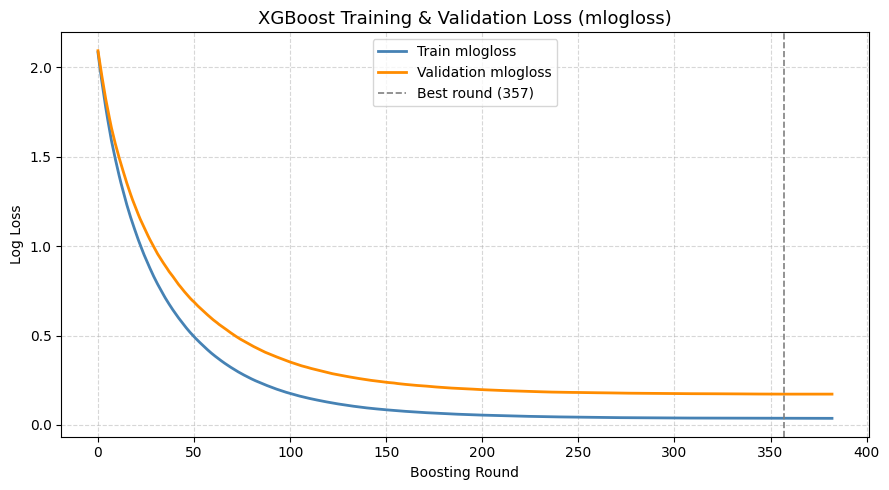

In [6]:
# ============================================================
# CELL 6 — FINAL MODEL TRAINING
# ============================================================
# The best hyperparameters are retrained on X_train.
# Early stopping monitors X_val ONLY — X_test remains held out.

final_clf = xgb.XGBClassifier(
    **study.best_params,
    n_estimators=500,
    tree_method='hist',
    device='cuda',
    eval_metric='mlogloss',
    early_stopping_rounds=25,
    random_state=SEED,
)

print("\n--- Training Final XGBoost Classifier ---")
start_t = time.time()
final_clf.fit(
    X_train, y_train,
    eval_set=[
        (X_train, y_train),   # validation_0 → train loss curve
        (X_val,   y_val),     # validation_1 → val loss curve (early-stop monitor)
    ],
    verbose=False
)
train_time = time.time() - start_t

evals            = final_clf.evals_result()
train_loss_hist  = evals['validation_0']['mlogloss']
val_loss_hist    = evals['validation_1']['mlogloss']
best_round       = final_clf.best_iteration

print(f"Training complete | Time: {train_time:.2f}s | Best round: {best_round}")
print(f"Final Train Loss : {train_loss_hist[best_round]:.4f}")
print(f"Final Val Loss   : {val_loss_hist[best_round]:.4f}")

# ── Loss Curve ────────────────────────────────────────────────
plt.figure(figsize=(9, 5))
plt.plot(train_loss_hist, label='Train mlogloss',      color='steelblue', lw=2)
plt.plot(val_loss_hist,   label='Validation mlogloss', color='darkorange', lw=2)
plt.axvline(best_round, color='grey', ls='--', lw=1.2, label=f'Best round ({best_round})')
plt.title('XGBoost Training & Validation Loss (mlogloss)', fontsize=13)
plt.xlabel('Boosting Round'); plt.ylabel('Log Loss')
plt.legend(); plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout(); plt.show()



--- Evaluating on Held-Out Test Set ---

  FINAL TEST-SET PERFORMANCE (paper-grade reporting)
  Accuracy     : 0.9438
  Macro Prec.  : 0.9473
  Macro Recall : 0.9475
  Macro F1     : 0.9470
  Macro TPR    : 0.9475
  Macro FPR    : 0.0071
  Macro AUROC  : 0.9986
  Inference T  : 0.17s


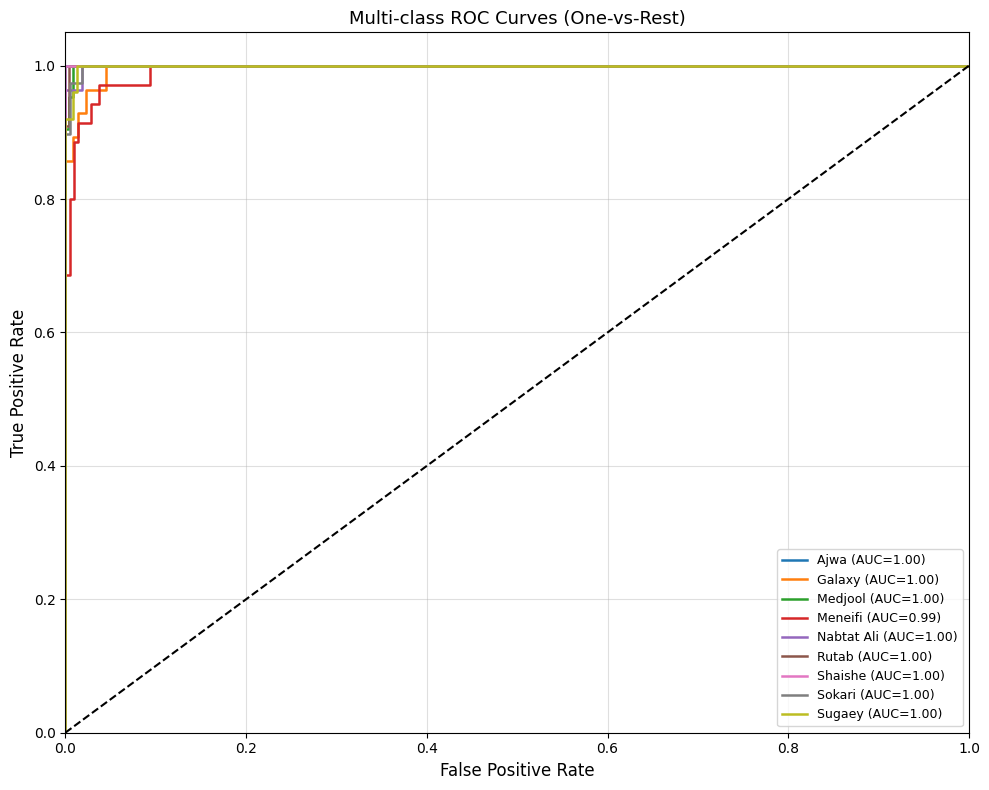


--- Per-Class Classification Report ---
              precision    recall  f1-score   support

        Ajwa     1.0000    1.0000    1.0000        26
      Galaxy     0.9231    0.8571    0.8889        28
     Medjool     0.9524    0.9524    0.9524        21
     Meneifi     0.8824    0.8571    0.8696        35
  Nabtat Ali     0.9630    0.9630    0.9630        27
       Rutab     0.9565    1.0000    0.9778        22
     Shaishe     0.9600    0.9231    0.9412        26
      Sokari     0.9268    0.9744    0.9500        39
      Sugaey     0.9615    1.0000    0.9804        25

    accuracy                         0.9438       249
   macro avg     0.9473    0.9475    0.9470       249
weighted avg     0.9434    0.9438    0.9432       249



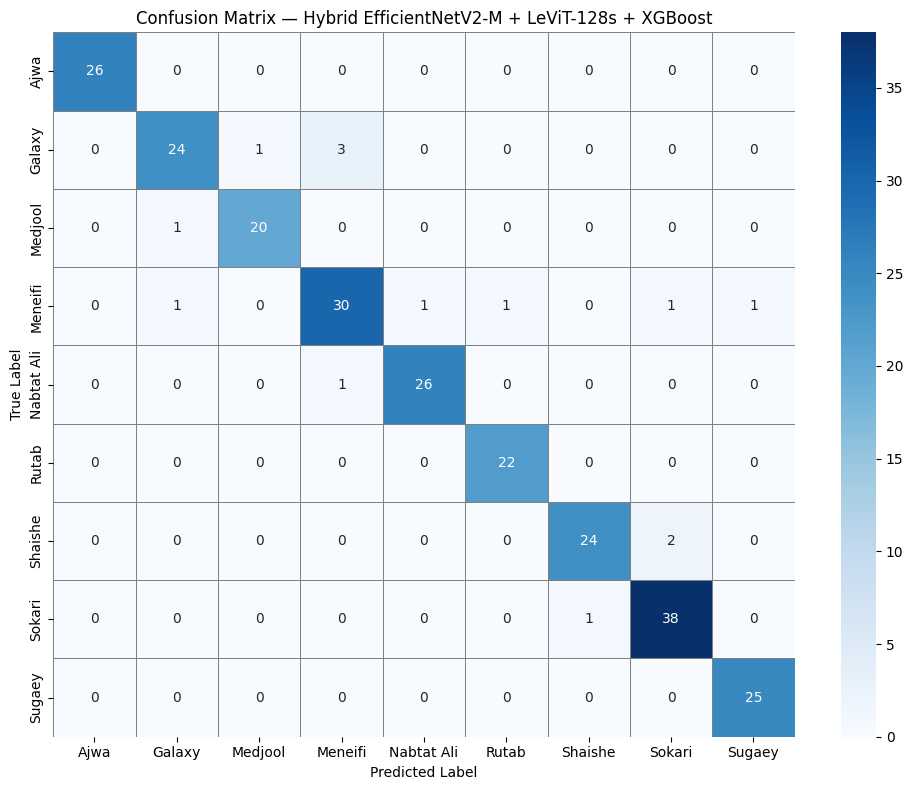

In [7]:
# ============================================================
# CELL 7 — HELD-OUT TEST SET EVALUATION
# ============================================================
# X_test has NEVER been seen during training or hyperparameter
# selection.  This is the single final evaluation reported in
# the paper.

print("\n--- Evaluating on Held-Out Test Set ---")
eval_start  = time.time()
y_pred      = final_clf.predict(X_test)
y_prob      = final_clf.predict_proba(X_test)
res         = get_metrics(y_test, y_pred, y_prob)
eval_time   = time.time() - eval_start

print("\n" + "="*55)
print("  FINAL TEST-SET PERFORMANCE (paper-grade reporting)")
print("="*55)
print(f"  Accuracy     : {res[0]:.4f}")
print(f"  Macro Prec.  : {res[1]:.4f}")
print(f"  Macro Recall : {res[2]:.4f}")
print(f"  Macro F1     : {res[3]:.4f}")
print(f"  Macro TPR    : {res[4]:.4f}")
print(f"  Macro FPR    : {res[5]:.4f}")
print(f"  Macro AUROC  : {res[6]:.4f}")
print(f"  Inference T  : {eval_time:.2f}s")
print("="*55)

# ── AUROC Curves (One-vs-Rest) ────────────────────────────────
y_test_bin = label_binarize(y_test, classes=np.arange(num_classes))
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    plt.plot(fpr_i, tpr_i, lw=1.8,
             label=f'{class_names[i]} (AUC={auc(fpr_i, tpr_i):.2f})')
plt.plot([0,1],[0,1],'k--',lw=1.5)
plt.xlim([0.0,1.0]); plt.ylim([0.0,1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate',  fontsize=12)
plt.title('Multi-class ROC Curves (One-vs-Rest)', fontsize=13)
plt.legend(loc='lower right', fontsize=9); plt.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

# ── Classification Report ────────────────────────────────────
print("\n--- Per-Class Classification Report ---")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

# ── Confusion Matrix ─────────────────────────────────────────
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, linecolor='grey')
plt.title('Confusion Matrix — Hybrid EfficientNetV2-M + LeViT-128s + XGBoost',
          fontsize=12)
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout(); plt.show()



--- Generating Global SHAP Suite ---


/tmp/ipykernel_4178/3478402952.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_list, X_test, plot_type="bar",


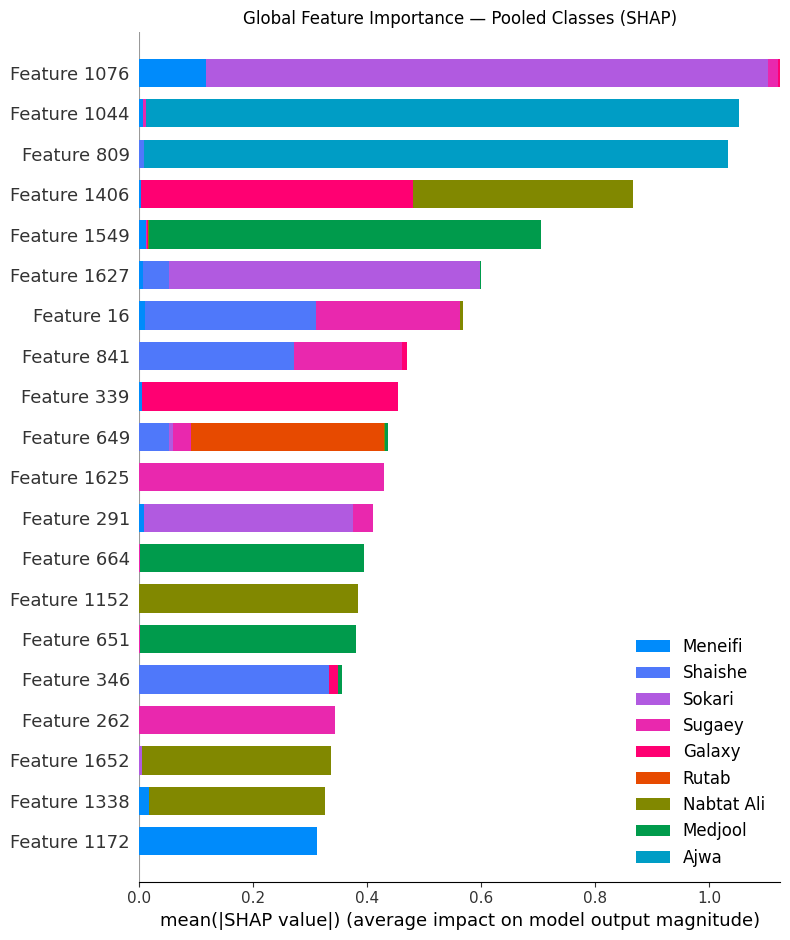

/tmp/ipykernel_4178/3478402952.py:24: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_list[0], X_test, show=True)


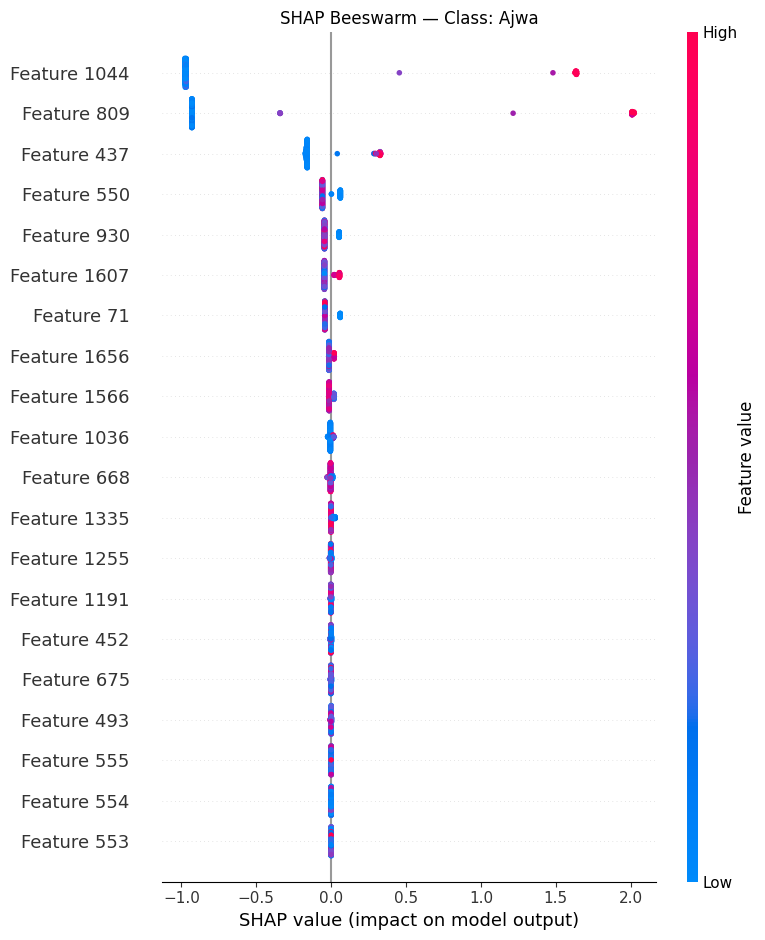

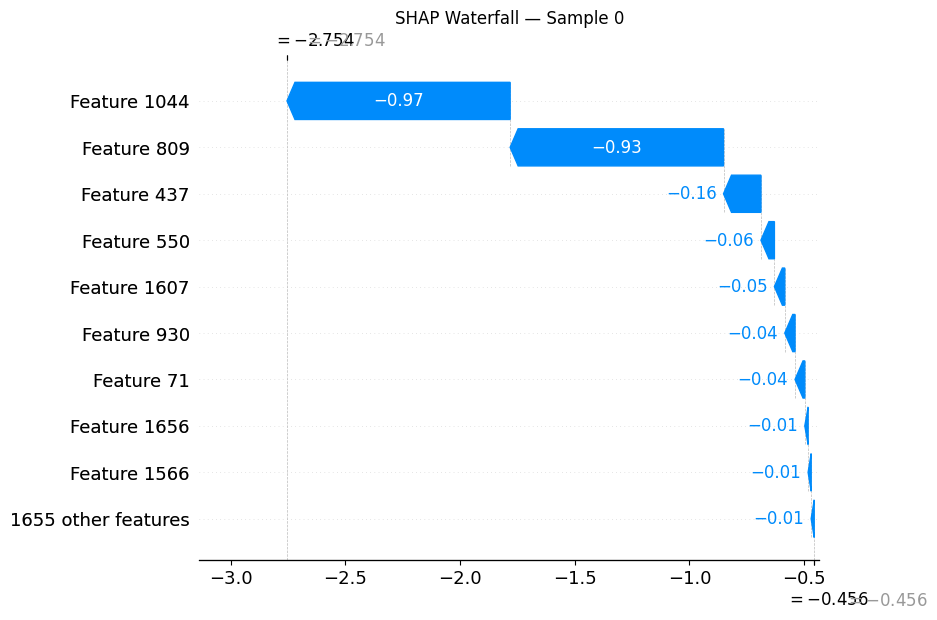

Global SHAP time: 2.44s


In [8]:
# ============================================================
# CELL 8 — GLOBAL SHAP ANALYSIS
# ============================================================
print("\n--- Generating Global SHAP Suite ---")
shap_start    = time.time()
explainer_tree = shap.TreeExplainer(final_clf)
shap_values   = explainer_tree.shap_values(X_test)

# shap_values shape: (n_samples, n_features, n_classes) for XGBoost multi-class
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_list = [shap_values[:, :, i] for i in range(shap_values.shape[2])]
else:
    shap_list = shap_values

# Plot A — Global Feature Importance (bar, pooled across classes)
plt.figure()
plt.title("Global Feature Importance — Pooled Classes (SHAP)", fontsize=12)
shap.summary_plot(shap_list, X_test, plot_type="bar",
                  class_names=class_names, show=True)

# Plot B — Beeswarm for first class
plt.figure()
plt.title(f"SHAP Beeswarm — Class: {class_names[0]}", fontsize=12)
shap.summary_plot(shap_list[0], X_test, show=True)

# Plot C — Waterfall for a single test sample
plt.figure()
plt.title("SHAP Waterfall — Sample 0", fontsize=12)
shap.plots._waterfall.waterfall_legacy(
    explainer_tree.expected_value[0], shap_list[0][0])

print(f"Global SHAP time: {time.time() - shap_start:.2f}s")



--- Local SHAP Heatmaps (9 classes) ---


  0%|          | 0/148 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:17, 17.97s/it]               


Class: Ajwa


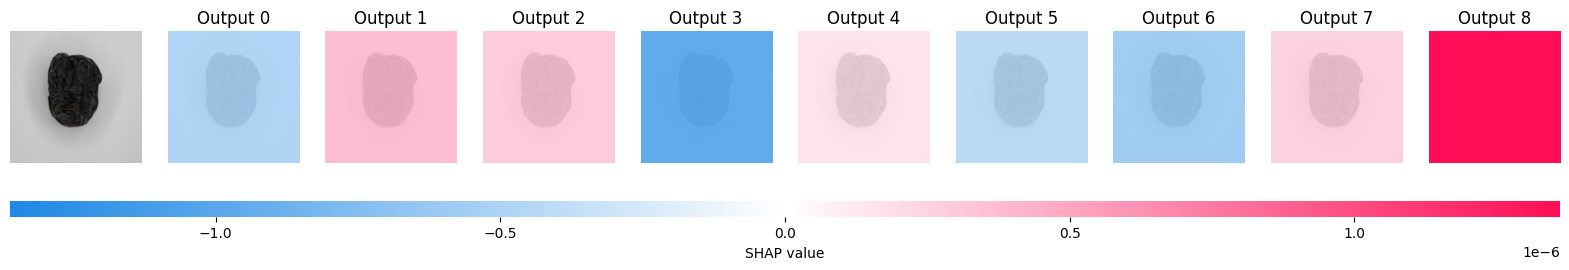

  0%|          | 0/148 [00:00<?, ?it/s]

Class: Galaxy


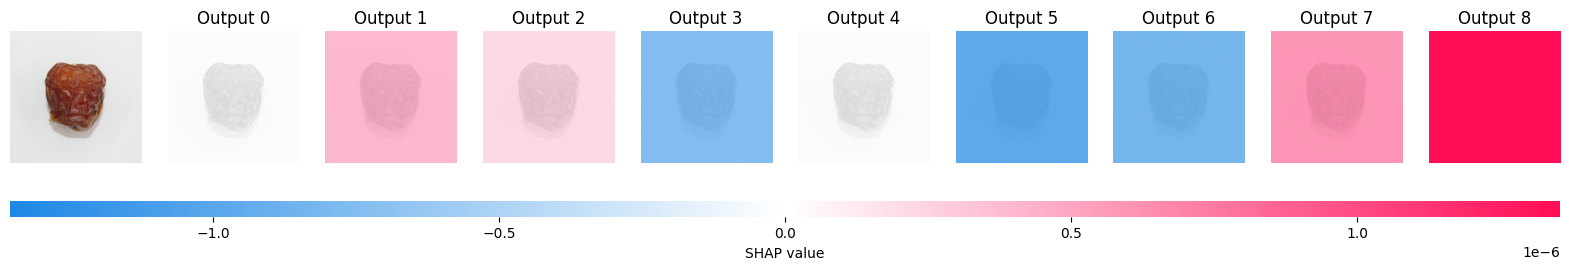

  0%|          | 0/148 [00:00<?, ?it/s]

Class: Medjool


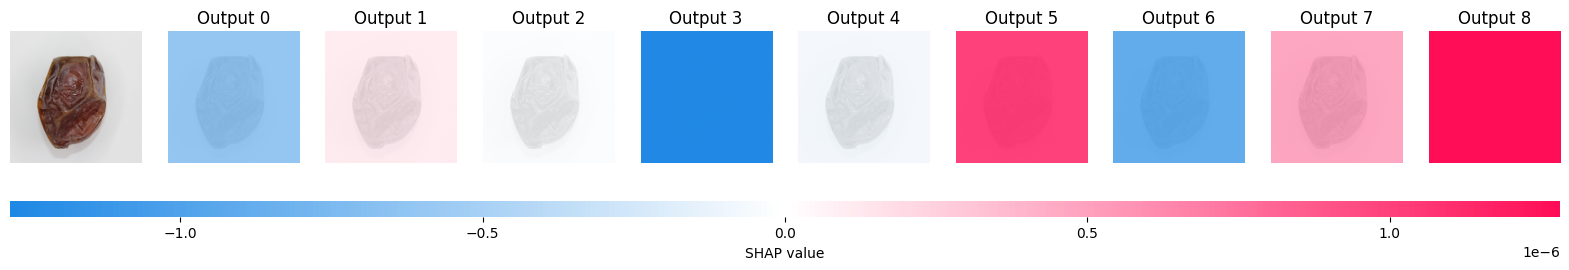

  0%|          | 0/148 [00:00<?, ?it/s]

Class: Meneifi


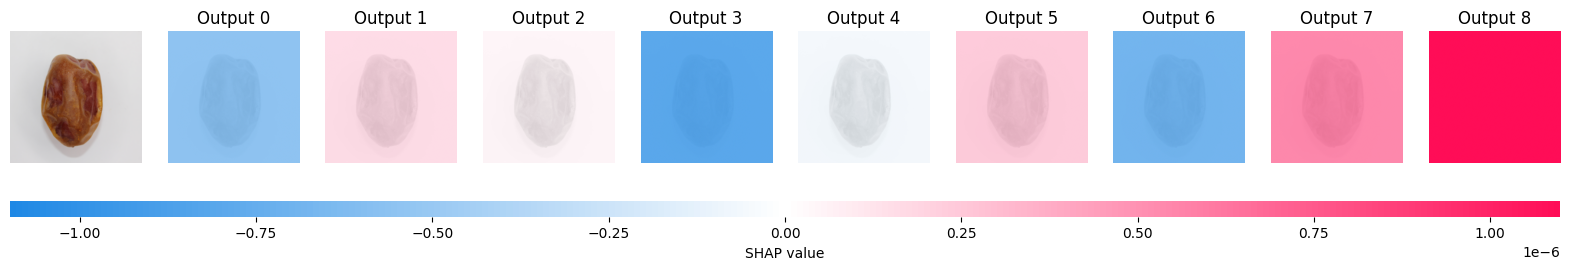

  0%|          | 0/148 [00:00<?, ?it/s]

Class: Nabtat Ali


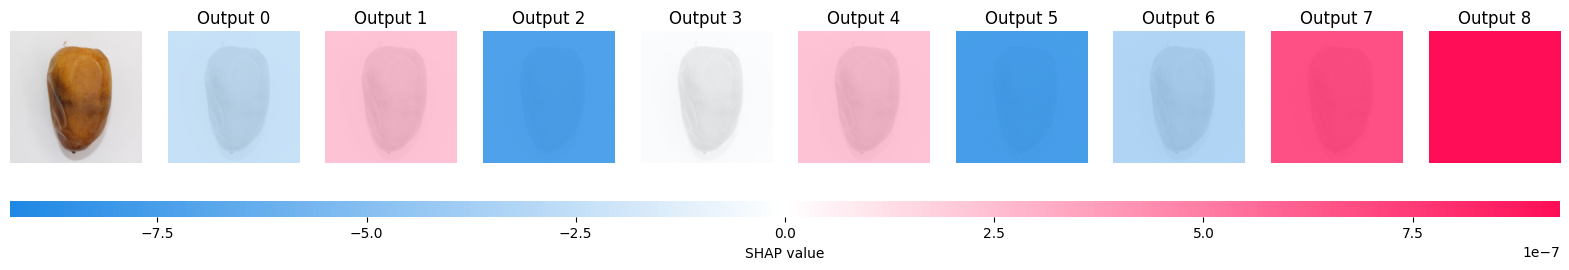

  0%|          | 0/148 [00:00<?, ?it/s]

Class: Rutab


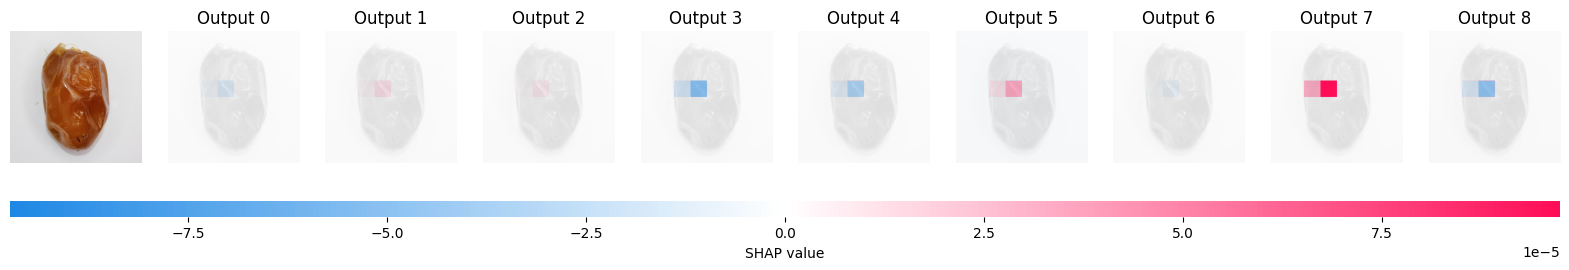

  0%|          | 0/148 [00:00<?, ?it/s]

Class: Shaishe


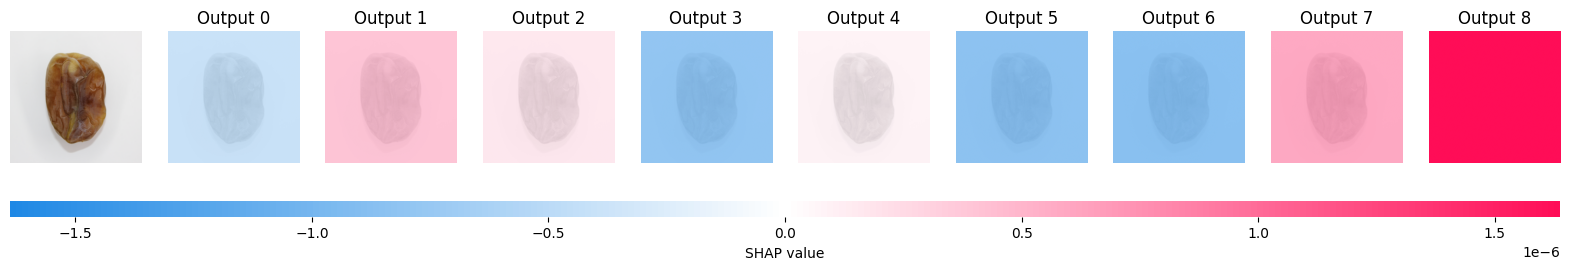

  0%|          | 0/148 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:12, 12.63s/it]               


Class: Sokari


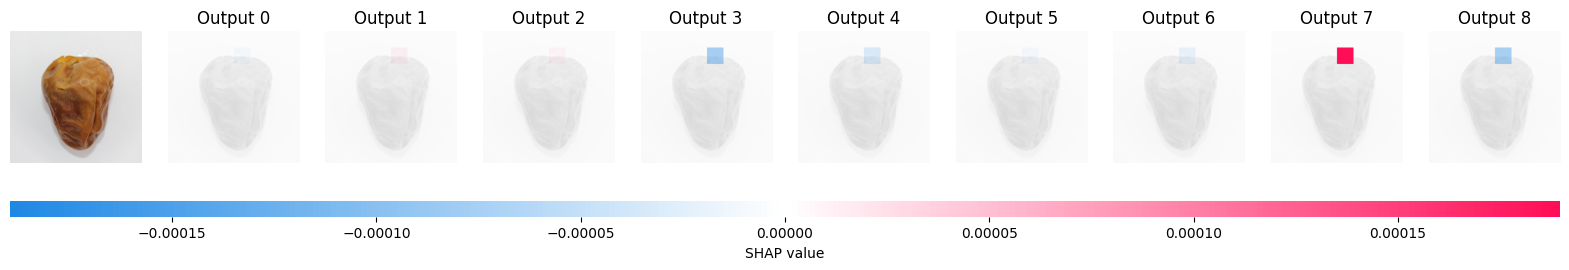

  0%|          | 0/148 [00:00<?, ?it/s]

Class: Sugaey


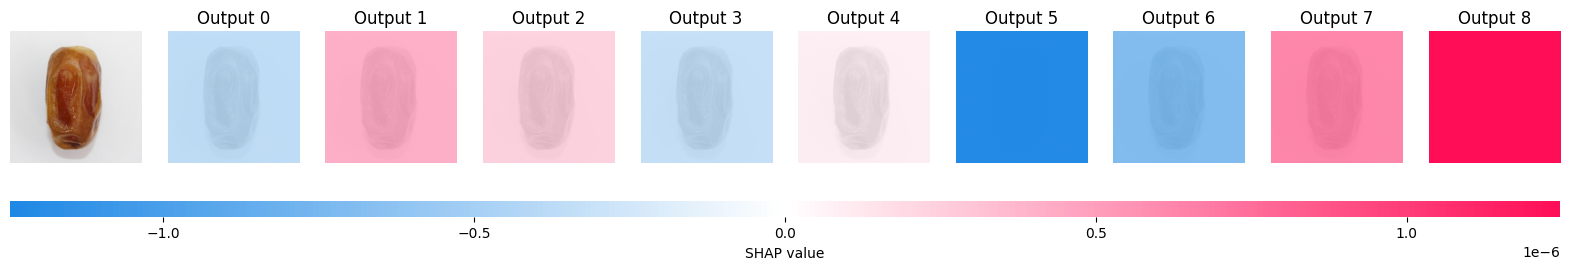

Local SHAP grid time: 100.01s

Done.


In [9]:
# ============================================================
# CELL 9 — LOCAL SHAP HEATMAP GRID (per-class pixel explanations)
# ============================================================
# Uses the raw images from the test split (infer_transform, no aug).

def predict_wrapper(imgs_np):
    """Bridge between SHAP image explainer and the hybrid model."""
    imgs_t = torch.from_numpy(imgs_np).permute(0, 3, 1, 2).float().to(DEVICE)
    mean_t = torch.tensor(eff_cfg.mean).view(1, 3, 1, 1).to(DEVICE)
    std_t  = torch.tensor(eff_cfg.std ).view(1, 3, 1, 1).to(DEVICE)
    imgs_t = (imgs_t - mean_t) / std_t
    with torch.no_grad():
        combined = torch.cat((m1(imgs_t), m2(imgs_t)), dim=1).cpu().numpy()
    return final_clf.predict_proba(combined)

img_explainer = shap.Explainer(
    predict_wrapper,
    shap.maskers.Image("inpaint_telea", (224, 224, 3))
)

def generate_class_grid():
    """Find one correctly predicted sample per class in the test split
    and produce a SHAP pixel-attribution heatmap for each."""
    indices_to_plot = []
    for target_cls in range(num_classes):
        for i in range(len(y_test)):
            if y_test[i] == target_cls and y_pred[i] == target_cls:
                indices_to_plot.append(i)
                break

    print(f"\n--- Local SHAP Heatmaps ({len(indices_to_plot)} classes) ---")
    local_start = time.time()

    for cls_idx, test_idx in enumerate(indices_to_plot):
        # Retrieve the original image via the test subset
        img_t, _ = test_subset[test_idx]           # tensor, infer_transform
        img_np   = img_t.permute(1, 2, 0).numpy()

        # Undo normalisation to get a displayable RGB image
        mean_arr = np.array(eff_cfg.mean)
        std_arr  = np.array(eff_cfg.std)
        img_unnorm = np.clip(std_arr * img_np + mean_arr, 0, 1)

        shap_vals = img_explainer(
            np.expand_dims(img_unnorm, axis=0),
            max_evals=150, batch_size=5
        )
        print(f"Class: {class_names[cls_idx]}")
        shap.image_plot(shap_vals, np.expand_dims(img_unnorm, axis=0))

    print(f"Local SHAP grid time: {time.time() - local_start:.2f}s")

generate_class_grid()

gc.collect()
torch.cuda.empty_cache()
print("\nDone.")
